# 03 — Modeling

Baseline logistic regression, then gradient boosting (XGBoost), with a patient-level train/test split and SHAP explanations.

In [1]:
import pandas as pd
import sys
sys.path.append('../src')
from data_prep import patient_level_split_ids
from model import train_logistic_baseline, train_xgboost, evaluate

In [2]:
df = pd.read_csv('../data/processed/model_ready.csv')
df.shape

(99343, 26)

## Patient-level train/test split
Critical: split by `patient_nbr`, not by row, since patients can appear multiple times.

In [3]:
train_ids, test_ids = patient_level_split_ids(df, test_size=0.2, random_state=42)
train_df = df[df['patient_nbr'].isin(train_ids)]
test_df = df[df['patient_nbr'].isin(test_ids)]
len(train_df), len(test_df)

(79219, 20124)

In [4]:
target = 'readmitted_30d'
drop_cols = ['patient_nbr', target]
numeric_cols = ['time_in_hospital','num_lab_procedures','num_procedures','num_medications',
                'number_outpatient','number_emergency','number_inpatient','number_diagnoses',
                'total_prior_visits']
categorical_cols = [c for c in train_df.columns if c not in numeric_cols + drop_cols]

X_train, y_train = train_df.drop(columns=drop_cols), train_df[target]
X_test, y_test = test_df.drop(columns=drop_cols), test_df[target]

## Baseline: Logistic Regression

In [5]:
logit_model = train_logistic_baseline(X_train, y_train, numeric_cols, categorical_cols)
logit_results = evaluate(logit_model, X_test, y_test)
print('PR-AUC:', round(logit_results['pr_auc'], 3))
print('ROC-AUC:', round(logit_results['roc_auc'], 3))
print(logit_results['classification_report'])

PR-AUC: 0.225
ROC-AUC: 0.658
              precision    recall  f1-score   support

           0       0.92      0.68      0.78     17783
           1       0.18      0.54      0.27      2341

    accuracy                           0.67     20124
   macro avg       0.55      0.61      0.53     20124
weighted avg       0.83      0.67      0.72     20124



## Gradient Boosting: XGBoost

In [6]:
xgb_model = train_xgboost(X_train, y_train, numeric_cols, categorical_cols)
xgb_results = evaluate(xgb_model, X_test, y_test)
print('PR-AUC:', round(xgb_results['pr_auc'], 3))
print('ROC-AUC:', round(xgb_results['roc_auc'], 3))
print(xgb_results['classification_report'])

PR-AUC: 0.234
ROC-AUC: 0.667
              precision    recall  f1-score   support

           0       0.92      0.65      0.76     17783
           1       0.18      0.58      0.27      2341

    accuracy                           0.64     20124
   macro avg       0.55      0.62      0.52     20124
weighted avg       0.84      0.64      0.71     20124



## SHAP explanations
Explain the XGBoost model's predictions to understand key risk drivers.

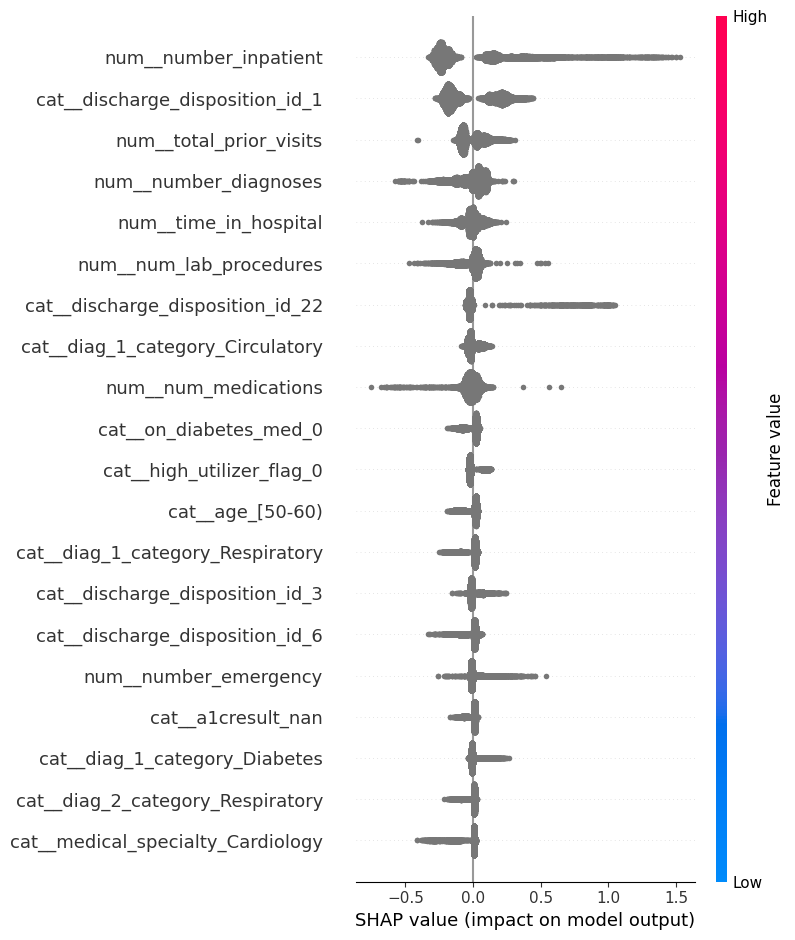

In [7]:
import shap

# Transform test data through the pipeline's preprocessor to get feature names
preprocessor = xgb_model.named_steps['preprocess']
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(xgb_model.named_steps['clf'])
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

## Save the model
Export for use in the dashboard's risk-scoring page.

In [8]:
import joblib
joblib.dump(xgb_model, '../data/processed/readmission_model.pkl')

['../data/processed/readmission_model.pkl']

In [ ]:
import pandas as pd
import joblib

df_full = pd.read_csv('../data/processed/model_ready.csv')
model = joblib.load('../data/processed/readmission_model.pkl')

# Add a unique row ID since model_ready.csv has no encounter_id column
df_full = df_full.reset_index(drop=True)
df_full['row_id'] = df_full.index

X_full = df_full.drop(columns=['patient_nbr', 'readmitted_30d', 'row_id'])
df_full['pred_proba'] = model.predict_proba(X_full)[:, 1]

high_cutoff = df_full['pred_proba'].quantile(0.85)
medium_cutoff = df_full['pred_proba'].quantile(0.60)

def risk_tier(p):
    if p >= high_cutoff:
        return 'High'
    elif p >= medium_cutoff:
        return 'Medium'
    return 'Low'

df_full['risk_tier'] = df_full['pred_proba'].apply(risk_tier)

risk_export = df_full[['row_id', 'patient_nbr', 'age', 'race', 'gender', 'pred_proba', 'risk_tier', 'readmitted_30d']]
risk_export.to_csv('../data/processed/risk_scores.csv', index=False)
risk_export['risk_tier'].value_counts()

risk_tier
Low       59606
Medium    24835
High      14902
Name: count, dtype: int64

In [12]:
risk_export.groupby('risk_tier')['readmitted_30d'].agg(['mean', 'count'])

,mean,count
risk_tier,,
High,0.266340,14902
Low,0.065295,59606
Medium,0.139038,24835
